# Fitting hypotony data

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel, Norm_Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter, Norm_Iso2DGaussianFitter
from prfpy.rf import gauss2D_iso_cart

import os
opj = os.path.join
import yaml
import pickle
from datetime import datetime

# from utils import *
# from plot_functions import *


In [30]:
# First we need to load the settings
prf_settings = 'eg_prf_settings.yml'
with open(prf_settings) as f:
    prf_info = yaml.safe_load(f)    

# Creating stimulus object


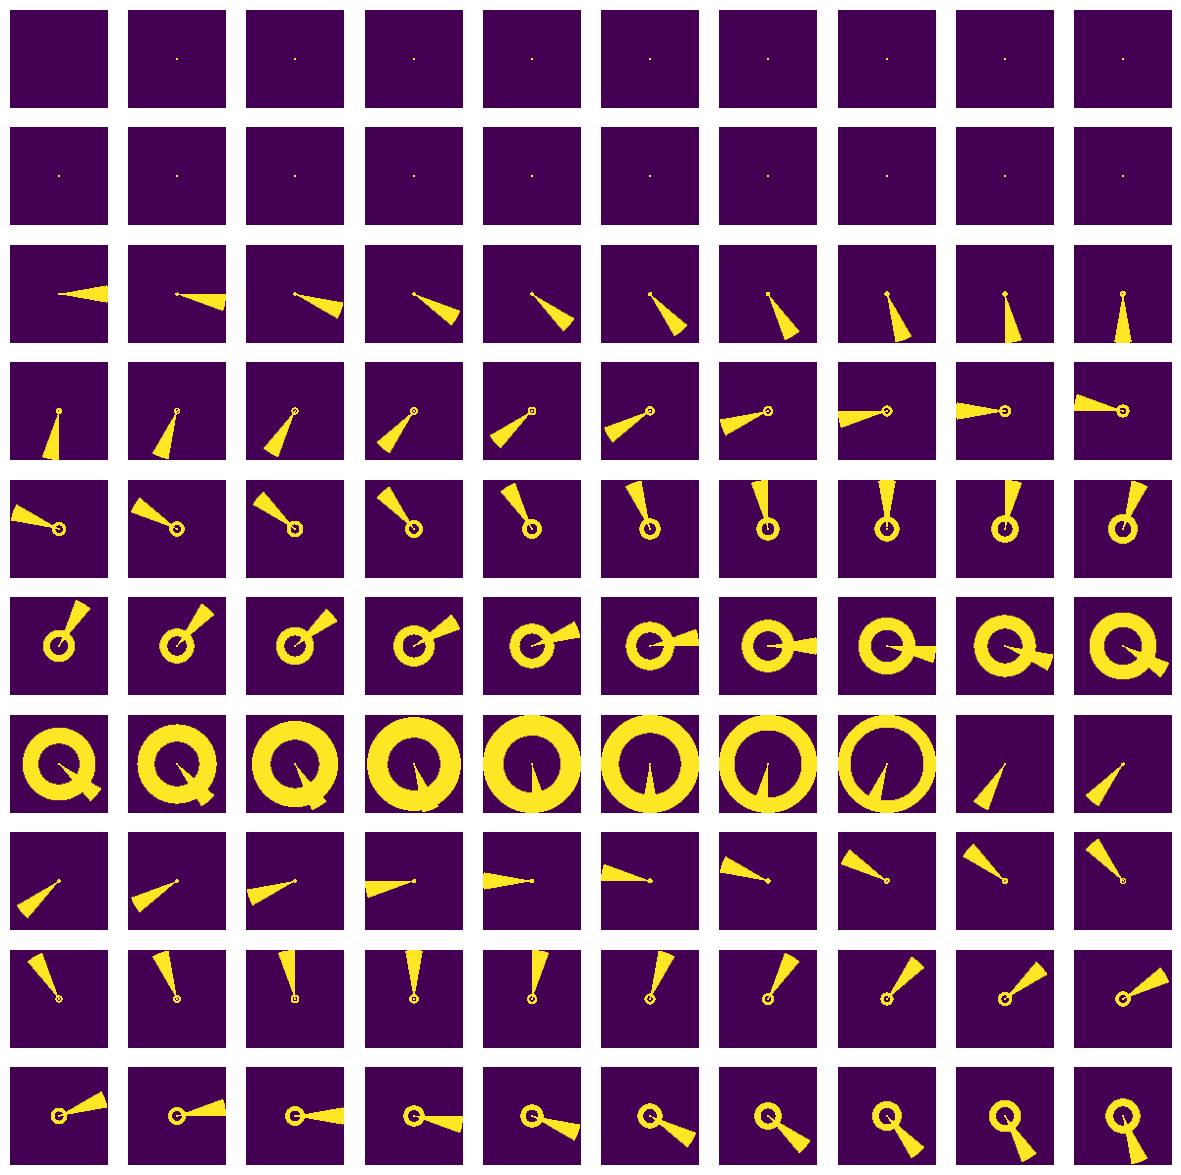

In [3]:
# If you already have the design matrix as a numpy array, you can simply load it...
dm = np.load('eg_prf_dm.npy')

# You can see we have a binarized matrix, of a bar moving across the screen...
fig = plt.figure()
rows = 10
cols = 10
fig.set_size_inches(15,15)
for i in range(100):
    ax = fig.add_subplot(rows, cols, i+1)
    ax.imshow(dm[:,:,i], vmin=0, vmax=1)
    ax.axis('off')


In [6]:
# Now we need to enter the design matrix in a way that prfpy can read it. 
# We do this using the PRFStimulus2D object
# Information we need
# -> Screen size (height), and distance (to the eye)
# This is so that we can convert into degrees of visual angle (dov)
# -> TR: This is so that we know the time (in s), of each 'frame' / pt in the time series
# Here we have 225 time points. So total length of scan was TR * 225 (1.5*225) 
prf_stim = PRFStimulus2D(
    screen_size_cm=prf_info['screen_size_cm'],          # Distance of screen to eye
    screen_distance_cm=prf_info['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
    design_matrix=dm,                                   # dm (npix x npix x time_points)
    TR=prf_info['TR'],                                  # TR
    )
print(f'Screen size in degrees of visual angle = {prf_stim.screen_size_degrees}')

# If for some reason you do not have the original dimensions, but you do have the dov, you can use this calculator:
# https://elvers.us/perception/visualAngle/ to make up some values for screen_size and distance, which will work...


Screen size in degrees of visual angle = 43.311978076844994


# Creating the (gaussian) model

In [8]:
'''    
    """__init__ for Iso2DGaussianModel
    constructor, sets up stimulus and hrf for this Model
    Parameters
    ----------
    stimulus : PRFStimulus2D
        Stimulus object specifying the information about the stimulus,
        and the space in which it lives.
    hrf : string, list or numpy.ndarray, optional
        HRF shape for this Model.
        Can be 'direct', which implements nothing (for eCoG or later convolution),
        a list or array of 3, which are multiplied with the three spm HRF basis functions,
        and an array already sampled on the TR by the user.
        (the default is None, which implements standard spm HRF)
    filter_predictions : boolean, optional
        whether to high-pass filter the predictions, default False
    filter_type, filter_params : see timecourse.py
    normalize_RFs : whether or not to normalize the RF volumes (generally not needed).
'''
gg = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_info['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_info['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_info['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    )

A note on the HRF

Generally we only to fit "hrf_1" (i.e., the derivative). The HRF is created using the 3 SPM basis functions, and the 3 hrf parameters determine how this works. We tend to fix hrf_pars[0] to = 1, as parameter can confound with the size and the amplitude of the PRF estimate. Similarly we generally fix hrf_2 (the dispersion) to =0, because it can confound with inhibitory PRF models. It is possible to fix all the HRF parameters (i.e., and use the default) and still get good quality PRF fits.   


# Loading data

In [49]:
sub = 'sub-hp01'
ses = 'ses-01'
task = 'pRFLE'
denoise_dir = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's4_conf_test', sub, ses
)
fs_dir = os.environ['SUBJECTS_DIR']
import pathlib
import glob
import nibabel as nib
def load_gii(task, denoise_dir):
    hemi_files = {}
    
    # find *fsnative.gii file in denoise_dir
    hemi_files = glob.glob(opj(denoise_dir, f'*{task}*fsnative*hemi-L*.gii'))

    hemi_files.sort()
    # load as .np arrays
    run_data = []
    for iR,hL in enumerate(hemi_files):
        hR = hL.replace('hemi-L', 'hemi-R')
        arr_L = np.vstack([i.data for i in nib.load(hL).darrays])
        arr_R = np.vstack([i.data for i in nib.load(hR).darrays])
        arr_LR = np.hstack([arr_L, arr_R]).T
        run_data.append(arr_LR)


    return run_data
run_data = load_gii(task, denoise_dir)
run_data_noDN = load_gii(
    task, 
    opj(os.environ['BIDS_DIR'], 'derivatives', 's2_coreg', sub, ses))


In [50]:
run_data_noDN

[array([[15246.14  , 15183.456 , 15000.009 , ..., 15448.653 , 15144.122 ,
         15020.388 ],
        [15168.448 , 15090.384 , 14915.1045, ..., 15374.69  , 15120.22  ,
         15035.388 ],
        [14113.852 , 13989.227 , 13884.349 , ..., 14354.208 , 14329.942 ,
         14405.423 ],
        ...,
        [10958.046 , 10817.02  , 10732.036 , ..., 10716.866 , 10699.057 ,
         10728.294 ],
        [11376.067 , 10873.119 , 11260.12  , ..., 11860.238 , 12124.27  ,
         11355.981 ],
        [15289.048 , 14962.883 , 15188.935 , ..., 15029.839 , 15103.097 ,
         15091.392 ]], shape=(277711, 352), dtype=float32),
 array([[15078.128 , 15056.899 , 15026.8   , ..., 14985.987 , 14984.366 ,
         15100.469 ],
        [14991.255 , 14974.266 , 14942.591 , ..., 14899.599 , 14901.457 ,
         15000.96  ],
        [14001.907 , 13990.2705, 13993.472 , ..., 13945.493 , 13980.714 ,
         13936.735 ],
        ...,
        [10838.773 , 10826.679 , 10691.573 , ..., 10755.411 , 10707.841 

In [51]:
from utils import *
psc_avg_ts = raw_ts_to_average_psc(
    raw_ts=run_data,        # Enter the runs as a list of np.ndarrays
    baseline=19,                # The first 20 time points, there is NO stimulation. So we use this to set the baseline
)
psc_avg_ts_noDN = raw_ts_to_average_psc(
    raw_ts=run_data_noDN,        # Enter the runs as a list of np.ndarrays
    baseline=19,                # The first 20 time points, there is NO stimulation. So we use this to set the baseline
)


/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/postproc/utils.py:305: RuntimeWarning: divide by zero encountered in divide
  psc_factor = np.nan_to_num( 100 / np.mean(ts, axis=t_dim))


psc_avg_ts shape = (277711, 352)
TR = 1 s


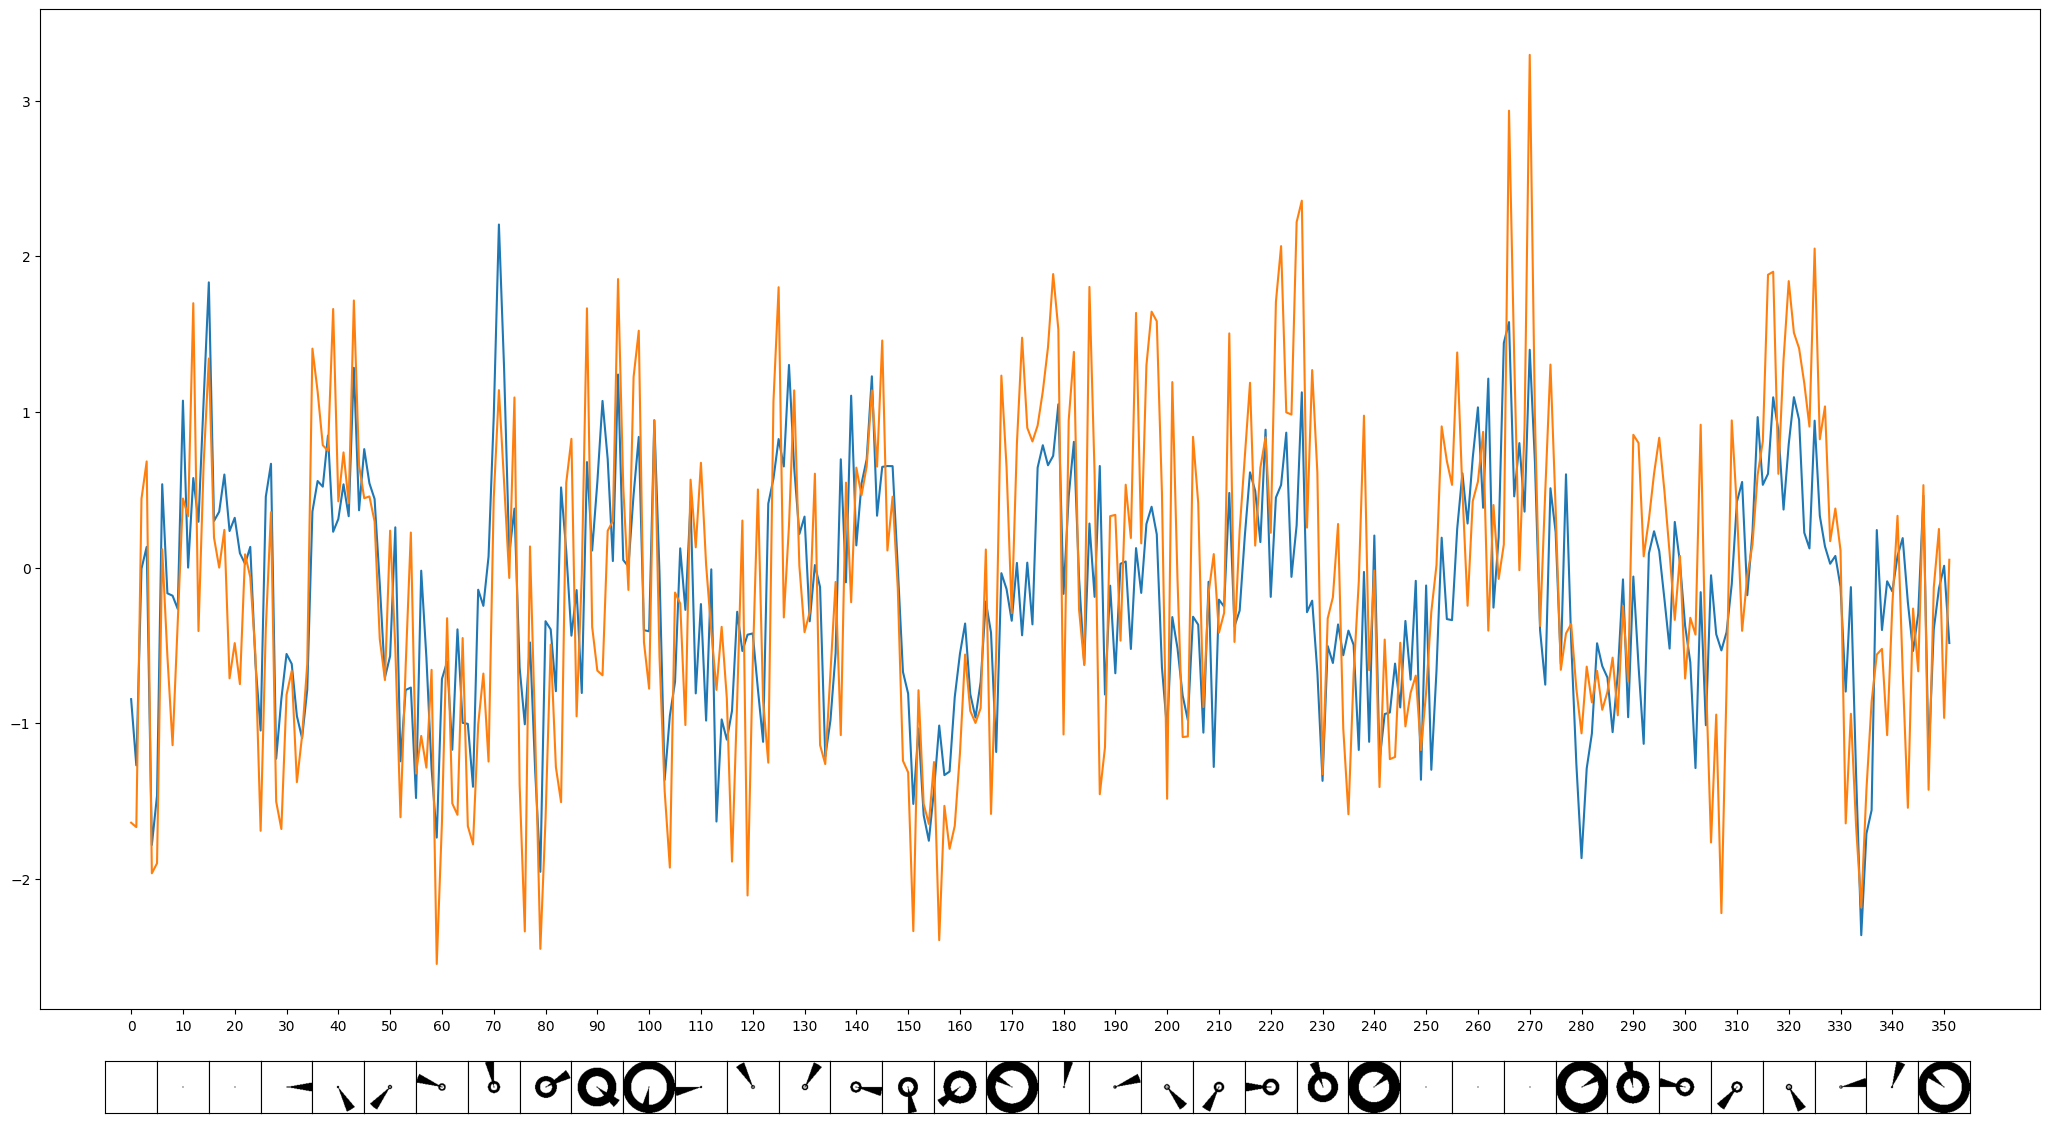

In [54]:
from plot_functions import *
TR_s = prf_info['TR']
print(f'psc_avg_ts shape = {psc_avg_ts.shape}')
print(f'TR = {TR_s} s')
time_pts = np.arange(psc_avg_ts.shape[1]) * TR_s
i_vx = 200

fig = plt.figure()
fig.set_size_inches(20,10)
ax = fig.add_axes([0,0,1,1])
ax.plot(time_pts, psc_avg_ts[i_vx,:])
ax.plot(time_pts, psc_avg_ts_noDN[i_vx,:])
# ax.plot(time_pts, run2[i_vx,:])
ax.set_xticks(np.arange(time_pts[0], time_pts[-1],10))
add_dm_to_ts(fig, ax, dm, TR=1.5, dx_axs=2)



In [67]:
from dpu_mini.fs_tools import *
v1_mask = dpu_load_roi(sub, 'V1', fs_dir)
data = psc_avg_ts[v1_mask,4:]

# Creating the gaussian fitter
Now we need to make a fitter, to load in the data


In [68]:
gf = Iso2DGaussianFitter(
    data=data,            # time series
    model=gg,                   # model (see above)
    n_jobs=prf_info['n_jobs'],  # number of jobs to use in parallelization 
    )

## Gaussian grid fit
The first stage is the 'grid fit'
Here we make a "grid" of possible PRF models, (different locations: polar angle, eccentricity, as well as sizes)

In [95]:
max_eccentricity = prf_stim.screen_size_degrees/2 # It doesn't make sense to look for PRFs which are outside the stimulated region
grid_nr = prf_info['grid_nr'] # Size of the grid (i.e., number of possible PRF models). Higher number means that the grid fit will be more exact, but take longer...
eccs    = max_eccentricity * np.linspace(0.25, 1, grid_nr)**2 # Squared because of cortical magnification, more efficiently tiles the visual field...
sizes   = max_eccentricity * np.linspace(0.1, 1, grid_nr)**2  # Possible size values (i.e., sigma in gaussian model) 
polars  = np.linspace(0, 2*np.pi, grid_nr)              # Possible polar angle coordinates

# We can also fit the hrf in the same way (specifically the derivative)
# -> make a grid between 0-10 (see settings file)
hrf_1_grid = np.linspace(prf_info['hrf']['deriv_bound'][0], prf_info['hrf']['deriv_bound'][1], 5)
# We generally recommend to fix the dispersion value to 0
hrf_2_grid = np.array([0.0])

# If you don't want to do any hrf fitting - set both to be NONE (uncomment below)
hrf_1_grid = None
hrf_2_grid = None


# *** Save your fitting parameters:
# We may run our analysis several times. If so we want to save the important information all together
# We will use a pickle file to do this.
prf_info['max_eccentricity']  = max_eccentricity
prf_info['eccs'] = eccs
prf_info['sizes'] = sizes
prf_info['polars'] = polars
prf_info['hrf_1_grid'] = hrf_1_grid
prf_info['hrf_2_grid'] = hrf_2_grid

We also want to put some boundaries on possible values
We set the baseline to 0, so we want to fix that here. 'fixed_grid_baseline=0'
In addition, there is the amplitude parameter (which scales the response). 
We want to put an upper limit for this too, so that we don't get strange responses

In [127]:
# Amplitude bounds for gauss grid fit - set [min, max]
gauss_grid_bounds = [[prf_info['prf_ampl'][0],prf_info['prf_ampl'][1]]] 


gf.grid_fit(
    ecc_grid=eccs,
    polar_grid=polars,
    size_grid=sizes,
    hrf_1_grid=hrf_1_grid,
    hrf_2_grid=hrf_2_grid,
    verbose=True,
    n_batches=prf_info['n_batches'],               # The grid fit is performed in parallel over n_batches of units.Batch parallelization is faster than single-unit parallelization and of sequential computing.
    fixed_grid_baseline=False, #prf_info['fixed_grid_baseline'], # Fix the baseline? This makes sense if we have fixed the baseline in preprocessing
    grid_bounds=gauss_grid_bounds
    )
# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
gf.gridsearch_params = filter_for_nans(gf.gridsearch_params)
gf.gridsearch_r2 = filter_for_nans(gf.gridsearch_r2)

print(f'Mean rsq = {gf.gridsearch_r2.mean():.3f}')

prf_info['gauss_grid_bounds'] = gauss_grid_bounds

Each batch contains approx. 663 voxels.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Mean rsq = -inf


[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    9.1s finished


In [128]:
gp = print_p()['gauss']

Using fs dir = /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
centering!
Faces with missing vx: 270528
Faces with long edges: 1417
0.028471284511736146
centering!
Faces with missing vx: 268496
Faces with long edges: 1352
0.03055336910289647
Just using undersurface file..
[np.float64(-1.0664721890805713), np.float64(0.0)]
[np.float64(-0.3720024666606477), np.float64(0.427570236255248)]
[np.float64(-1.0664721890805713), np.float64(1.091046718199994)]
[np.float64(-0.4815846000176277), np.float64(0.427570236255248)]


{'cmap': 'viridis', 'vmin': np.float64(0.0), 'vmax': np.float64(0.0)}

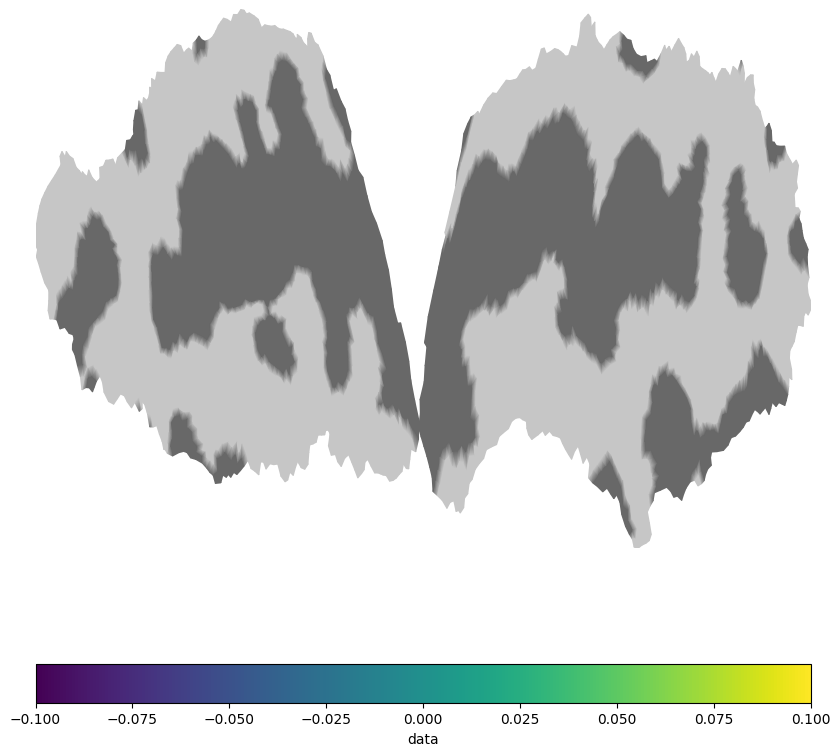

In [129]:
from dpu_mini.mesh_maker import *
gm = GenMeshMaker(sub, fs_dir)
gm.make_flat_map(v1_mask, morph=3)
gm.rescale_mesh_info('flat')
gm.flat_mpl()

[np.float64(-1.0664721890805713), np.float64(0.0)]
[np.float64(-0.3720024666606477), np.float64(0.427570236255248)]
[np.float64(-1.0664721890805713), np.float64(1.091046718199994)]
[np.float64(-0.4815846000176277), np.float64(0.427570236255248)]


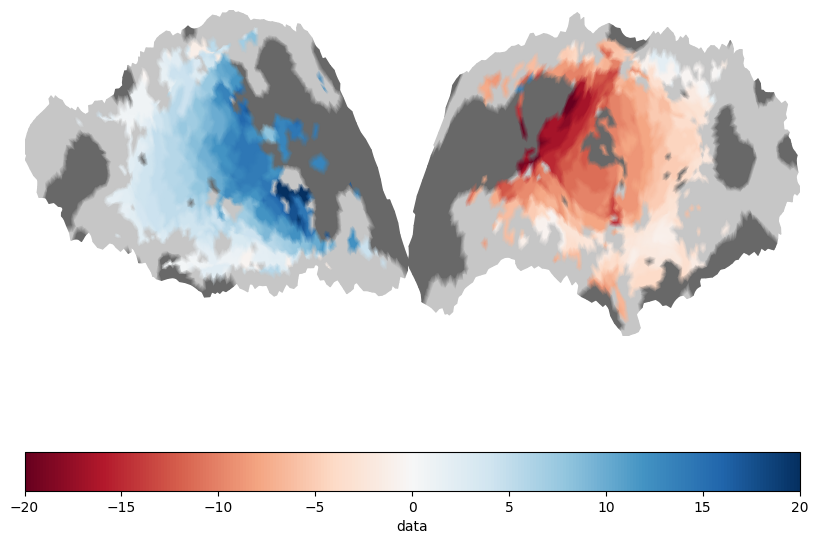

In [130]:
gm.flat_mpl(
    data=gf.gridsearch_params[:,0],
    data_sub_mask=v1_mask,
    data_mask=gf.gridsearch_r2>0.1, 
    cmap='RdBu', vmin=-20,vmax=20, 
)
plt.gca().set_aspect('equal')

In [ ]:
# Save grids: 
if prf_info['save_grids']:
    print('saving grids')
    grid_file = './grid_fit.pkl'
    grid_dict = {}
    grid_dict['settings'] = prf_info # Save the settings into the pickle file
    grid_dict['pars'] = gf.gridsearch_params # Save the parameters into the pickle file
    grid_dict['date'] = datetime.now().strftime('%Y-%m-%d_%H-%M') # save the date into pickle
    f = open(grid_file, "wb")
    pickle.dump(grid_dict, f)
    f.close()



## Gaussian Iterative Fit
Now we can do the iterative fit. This takes the best fitting grid (from the above stage), and iteratively tweaks the parameters until the best fit is founds. 
This takes a bit longer than the grid fit. We also need to setup the bounds for all the parameters. 

In [134]:
gauss_bounds = [
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # x bound
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # y bound
    (1e-1, max_eccentricity*3),                             # prf size bounds
    (prf_info['prf_ampl'][0],prf_info['prf_ampl'][1]),      # prf amplitude
    (prf_info['bold_bsl'][0],prf_info['bold_bsl'][1]),      # bold baseline (fixed)
    (prf_info['hrf']['deriv_bound'][0], prf_info['hrf']['deriv_bound'][1]), # hrf_1 bound
    (prf_info['hrf']['disp_bound'][0], prf_info['hrf']['disp_bound'][1]), # hrf_2 bound
]
prf_info['gauss_bounds'] = gauss_bounds


In [135]:
gf.iterative_fit(
    rsq_threshold=prf_info['rsq_threshold'],    # Minimum variance explained. Puts a lower bound on the quality of PRF fits. Any fits worse than this are thrown away...     
    verbose=True,
    bounds=gauss_bounds,       # Bounds (on parameters)
    )               
# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
gf.iterative_search_params = filter_for_nans(gf.gridsearch_params)
# 95 mins for v1 - 6630 vx

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   39.8s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  3.4min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  8.6min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed: 18.2min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed: 28.6min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed: 38.3min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed: 51.7min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed: 70.1min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed: 87.9min
[Parallel(n_jobs=4)]: Done 4312 out of 4312 | elapsed: 95.6min finished


In [148]:
print(v1_mask.sum())

6630


In [ ]:
# fit_dir = opj(
#     os.environ['BIDS_DIR'], 'derivatives', 's5_prfpy', sub, ses
# )
# if not os.path.exists(fit_dir):
#     os.makedirs(fit_dir)
# giter_pkl = opj(fit_dir, 'giterB_pRFLE.pkl')
# # with open('wb', giter_pkl) as file:
# #     pickle.dump(gf.iterative_search_params, file)
# giter_np = opj(fit_dir, 'giter_pRFLE.npy')
# np.save(giter_np, gf.iterative_search_params)


[np.float64(-1.0664721890805713), np.float64(0.0)]
[np.float64(-0.3720024666606477), np.float64(0.427570236255248)]
[np.float64(-1.0664721890805713), np.float64(1.091046718199994)]
[np.float64(-0.4815846000176277), np.float64(0.427570236255248)]


{'cmap': 'RdBu', 'vmin': -20, 'vmax': 20}

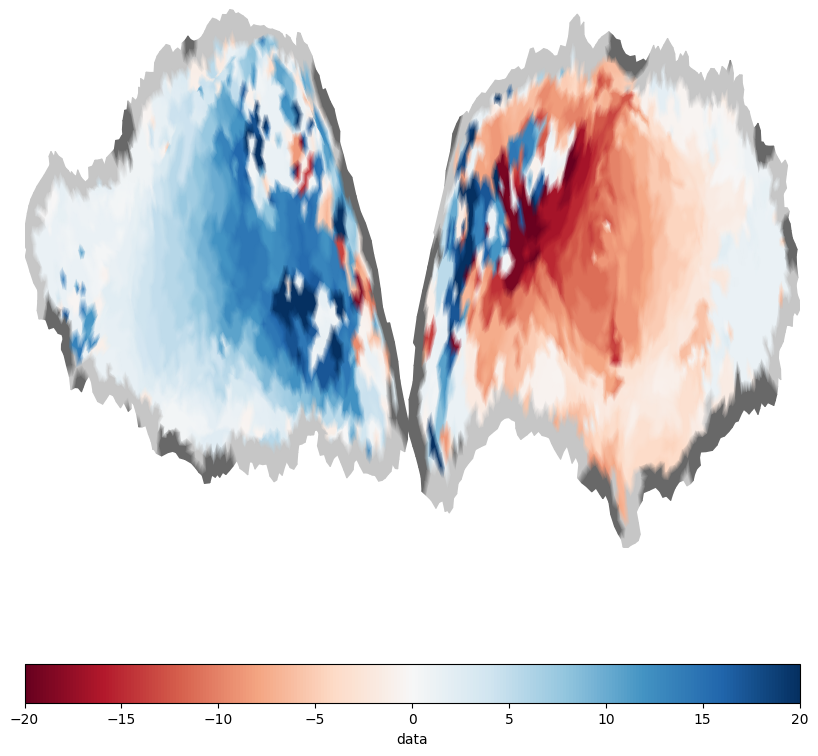

In [147]:
gm.flat_mpl(
    data=gf.iterative_search_params[:,0],
    data_sub_mask=v1_mask, 
    vmin=-20, vmax=20, cmap='RdBu', 
)

# WELL DONE!
We now have a set of prf fits. 


(-5.725064326420601, 5.725064326420601)

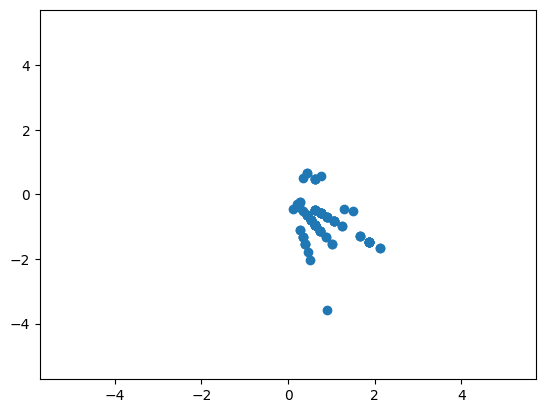

In [28]:
# The parameters are stored as a np.ndarray with units x parameters
# gf.iterative_search_params[:,0] -> x position of prf
# gf.iterative_search_params[:,1] -> y position of prf
# gf.iterative_search_params[:,2] -> size of prf
# gf.iterative_search_params[:,3] -> amplitude of prf
# gf.iterative_search_params[:,4] -> baseline of prf
# gf.iterative_search_params[:,5] -> rsq of prf

g_idx = print_p()['gauss'] # this dictionary provides a look up table for the different gaussian parameters
# Plot the x,y location of all the PRFs, which have a good fit...
good_fit_idx = gf.iterative_search_params[:, g_idx['rsq']] > 0.1
good_fit_x = gf.iterative_search_params[good_fit_idx, g_idx['x']]
good_fit_y = gf.iterative_search_params[good_fit_idx, g_idx['y']]

plt.scatter(good_fit_x, good_fit_y)
plt.xlim(-max_eccentricity,max_eccentricity)
plt.ylim(-max_eccentricity,max_eccentricity)

In [29]:
# We can now create the predicted timeseries, and compare these with the data
prf_params = gf.iterative_search_params
pred_tc = gg.return_prediction(
    mu_x = prf_params[:,0], # x position
    mu_y = prf_params[:,1], # y position
    size = prf_params[:,2], # prf size
    beta = prf_params[:,3], # prf amplitude
    baseline = prf_params[:,4], # prf baseline (set to 0)
    hrf_1 = prf_params[:,5],
    hrf_2 = prf_params[:,6],
)

# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
pred_tc = filter_for_nans(pred_tc)

In [ ]:
# # Now to save everything in a nice convenient pickle file
# print('saving iterative search params')
# iter_file = './iter_fit.pkl'
# iter_dict = {}
# iter_dict['settings'] = prf_info # Save the settings into the pickle file
# iter_dict['pars'] = gf.iterative_search_params # Save the parameters into the pickle file
# iter_dict['preds'] = pred_tc # Save the predicted time series into the pickle file
# iter_dict['date'] = datetime.now().strftime('%Y-%m-%d_%H-%M') # save the date into pickle
# f = open(iter_file, "wb")
# pickle.dump(iter_dict, f)
# f.close()


saving iterative search params


In [ ]:
# # To load this file all you need to do is:
# pkl_file = open(iter_file,'rb')
# loaded_iter_dict = pickle.load(pkl_file)
# pkl_file.close()     

# # Now you can access all the useful information together in one place


Have a look at the model fits:
* vary the voxel you are looking at (i_vx)
* also look at how the parameters (in the title), determine the location and size of the RF
* varying "time_pt", you can see where the stimulus is, at different times
* Note that the HRF means that responses of the model will be delayed...

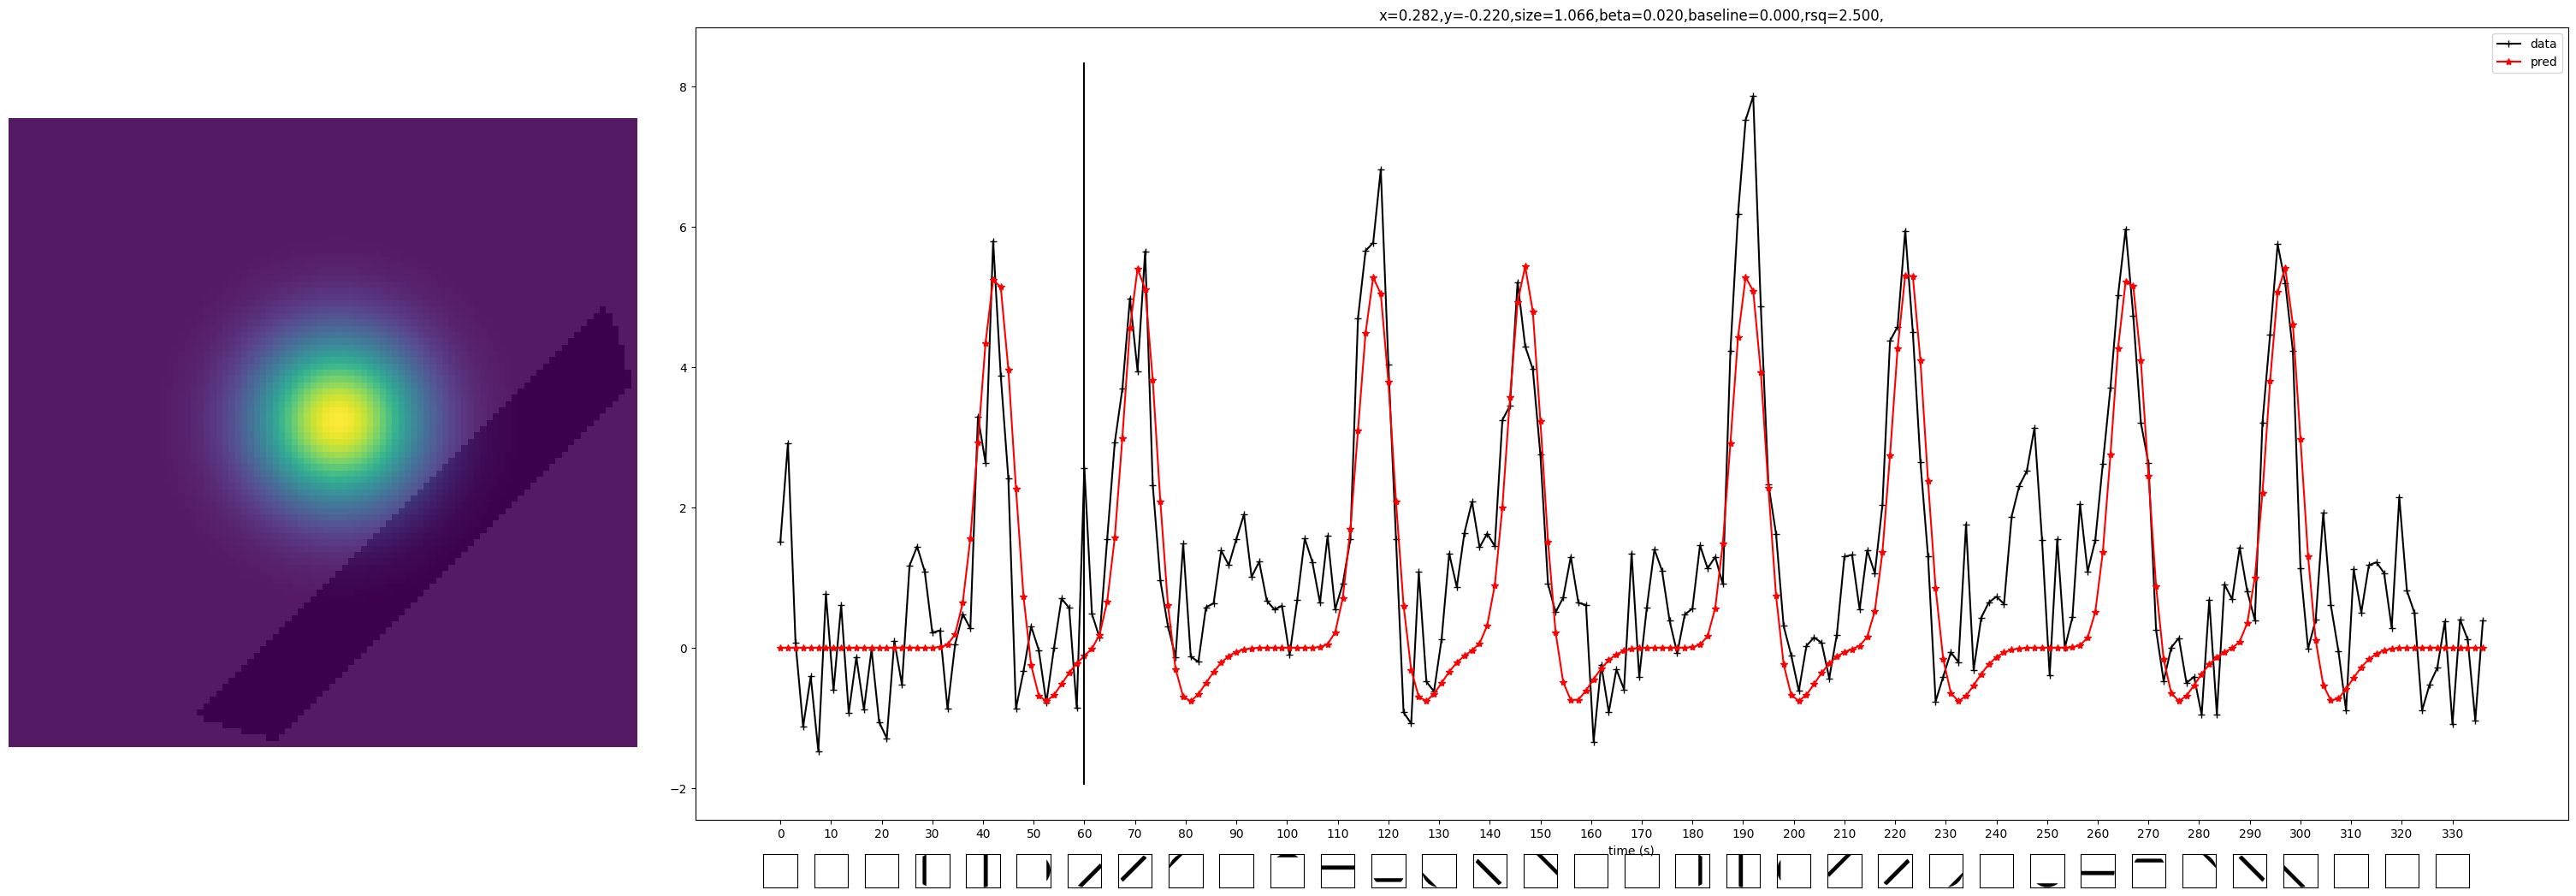

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=(30,10))
subfigs = fig.subfigures(1, 2, width_ratios=[10,30])
i_vx = 99

# ************* TIME COURSE PLOT *************
time_pts = np.arange(data.shape[1]) * TR_s    
ax2 = subfigs[1].add_subplot()
ax2.plot(time_pts, data[i_vx,:], '-+k', label= 'data')
ax2.plot(time_pts, pred_tc[i_vx,:], '-*r', label= 'pred')
ax2.set_xlabel('time (s)')
ax2.legend()

gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'rsq']
title_txt = ''
for i,p in enumerate(gauss_param_name):
    title_txt += f'{p}={prf_params[i_vx,i]:.3f},'
ax2.set_title(title_txt)

# ********* PRF PLOT **********
rf = gauss2D_iso_cart(
    x=prf_stim.x_coordinates,
    y=prf_stim.y_coordinates,
    mu=(prf_params[i_vx,0], prf_params[i_vx,1]),
    sigma=prf_params[i_vx,2])
ax1 = subfigs[0].add_subplot()
ax1.imshow(rf, vmin=0, vmax=1, extent=[-5,5,-5,5])
ax1.axis('off')

time_pt = 40
if time_pt != None:
    ax1.imshow(dm[:,:,time_pt], vmin=0, vmax=1,cmap='Greys', alpha=0.1, extent=[-5,5,-5,5])
    ax_lim = ax2.get_ylim()
    ax2.plot((time_pt*TR_s, time_pt*TR_s), (ax_lim), 'k')


ax2.set_xticks(np.arange(time_pts[0], time_pts[-1],10))
add_dm_to_ts(fig, ax2, dm, TR=1.5, dx_axs=2)    

# Guassian PRF widget
Here is a toy for you to get an intuition for the fitting procedure. Run the cell below, and you will see a plot of a real time series (black) and a red time series (prediction). You can vary the model parameters to try and make the red look as similar as the black as possible. Observe how the PRF shape changes. And how the 

In [32]:
import ipywidgets as widgets
from IPython.display import display, HTML


In [ ]:
widg_model = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_info['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_info['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_info['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    )

time_pts = np.arange(data.shape[1]) * TR_s    

def g_prf_widget(w_params):
    gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'hrf-deriv', 'hrf-disp']

    i_vx = int(w_params[-1])
    try: 
        print(f'For vx id = {i_vx}, best fit params are...')
        for i,p in enumerate(gauss_param_name):
            print(f'{p}={prf_params[i_vx,i]:.3f},')
    except Exception as e:
        pass


    data_to_plot = data[i_vx,:]
    fig = plt.figure(constrained_layout=True, figsize=(30,10))
    subfigs = fig.subfigures(1, 2, width_ratios=[10,30])

    # ************* TIME COURSE PLOT *************
    
    ax2 = subfigs[1].add_subplot()
    ax2.plot(time_pts, data_to_plot, '-+k', label= 'data')
    w_params = np.array(w_params)
    # w_params = w_params[...,np.newaxis]
    # Create pred tc:
    w_pred = widg_model.return_prediction(
        mu_x = w_params[0], # x position
        mu_y = w_params[1], # y position
        size = w_params[2], # prf size
        beta = w_params[3], # prf amplitude
        baseline = w_params[4], # prf baseline (set to 0)
        hrf_1 = w_params[5],
        hrf_2 = w_params[6],        
    )
    w_pred = np.squeeze(w_pred)
    ax2.plot(time_pts, w_pred, '-*r', label= 'pred')
    ax2.set_xlabel('time (s)')
    ax2.legend()
    ax2.set_xticks(np.arange(time_pts[0], time_pts[-1],10))
    add_dm_to_ts(fig, ax2, dm, TR=1.5, dx_axs=2)

    gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'hrf-deriv', 'hrf-disp']
    title_txt = ''
    for i,p in enumerate(gauss_param_name):
        title_txt += f'{p}={w_params[i]:.3f},'
    rsq = get_rsq(data_to_plot, w_pred)
    title_txt += f'rsq={rsq:.3f}'
    ax2.set_title(title_txt)

    # ********* PRF PLOT **********
    rf = np.flipud(gauss2D_iso_cart(
        x=prf_stim.x_coordinates,
        y=prf_stim.y_coordinates,
        mu=(w_params[0], w_params[1]),
        sigma=w_params[2]))
    ax1 = subfigs[0].add_subplot()
    ax1.imshow(rf, vmin=0, vmax=1, extent=[-5,5,-5,5])
    # ax1.axis('off')
    
    # SHOW
    plt.show()

In [34]:
# ***************** WIDGETS & PARAMETERS VALUES *****************
# Starting params to show the "cartoon" model with dip in the centre

w_params = np.array((
    0,      #mu_x
    0,      #mu_y
    1,      #size
    .1,     #beta
    0,      #baseline
    1,      #hrf_1
    0,      #hrf_2
    0,    #i_vx
))

w_param_title = np.array([
    'mu_x',
    'mu_y',
    'size',
    'beta',
    'baseline',
    'hrf_1',
    'hrf_2',
    'i_vx',
])

w_param_min_max_step = np.array([
    [-6,6,.1],  #mu_x
    [-6,6,.1],  #mu_y
    [0,10,.1], #size
    [0,10,.01], #beta
    [-2,2,.1],  #baseline
    [0,10,.1],  #hrf_1
    [0,10,.1],   #hrf_2
    [0,100,1],  # i_vx    
])

widg_controls=[]
for i in range(len(w_params)):    
    sl=widgets.BoundedFloatText(description=w_param_title[i],
                           min=w_param_min_max_step[i,0], 
                           max=w_param_min_max_step[i,1], 
                           step=w_param_min_max_step[i,2], 
                           value=w_params[i],
                           orientation = "vertical",
                           continuous_update=False)    
    widg_controls.append(sl)
    
widg_Dict = {} 
for c in widg_controls:
    widg_Dict[c.description] = c  

left_widg = widgets.VBox(tuple([widg_controls[i] for i in range(4)]))
right_widg = widgets.VBox([widg_controls[i] for i in range(4,8)])
widg_uif = widgets.HBox([left_widg, right_widg])

def widg_update_N(**xvalor):
    xvalor=[]
    for i in range(len(widg_controls)):
        xvalor.append(widg_controls[i].value)
    
    g_prf_widget(xvalor)

widg_outf = widgets.interactive_output(widg_update_N,widg_Dict)
display(widg_uif, widg_outf)

Output()

# Normalization stage

In [ ]:
gg_ext = Norm_Iso2DGaussianModel(
    stimulus=prf_stim,                                  
    hrf=prf_info['hrf']['pars'],                    
    normalize_RFs=prf_info['normalize_RFs'],        
    )        
# The extra bounds we need for the grid fit stage
# i.e., the bounds for the surround amplitude and size
ext_grid_bounds = [
    prf_info['prf_ampl'],
    prf_info['norm']['surround_baseline_bound']
]
# The grids on the extra parameters we want to fit
ext_grids = [
    np.array(prf_info['norm']['surround_amplitude_grid'], dtype='float32'),
    np.array(prf_info['norm']['surround_size_grid'], dtype='float32'),
    np.array(prf_info['norm']['neural_baseline_grid'], dtype='float32'),
    np.array(prf_info['norm']['surround_baseline_grid'], dtype='float32'),            
]


gf_ext = Norm_Iso2DGaussianFitter(
    data=data,           
    model=gg_ext,                  
    n_jobs=prf_info['n_jobs'],
    previous_gaussian_fitter = gf,
    use_previous_gaussian_fitter_hrf = True,  # Use the previous HRF that has been fit...
    )

gf_ext.grid_fit(
    *ext_grids,
    verbose=True,
    n_batches=prf_info['n_jobs'],
    rsq_threshold=prf_info['rsq_threshold'],
    fixed_grid_baseline=prf_info['fixed_grid_baseline'],
    grid_bounds=ext_grid_bounds,
)



Using HRF from previous gaussian iterative fit
Each batch contains approx. 25 voxels.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    3.1s remaining:    3.1s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    3.2s finished


### Norm iter fits

In [36]:
ext_custom_bounds = [
    (prf_info['prf_ampl']),                             # surround amplitude
    (1e-1, max_eccentricity*6),                             # surround size
    (prf_info['norm']['neural_baseline_bound']),        # neural baseline (b) 
    (prf_info['norm']['surround_baseline_bound']),      # surround baseline (d)
] 
# Combine the bounds 
# first create the standard bounds
standard_bounds = [
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # x bound
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # y bound
    (1e-1, max_eccentricity*3),                             # prf size bounds
    (prf_info['prf_ampl']),                             # prf amplitude
    (prf_info['bold_bsl']),                             # bold baseline (fixed)
]    
# & the hrf bounds. these will be overwritten later by the vx wise hrf parameters
# ( inherited from previous fits)
hrf_bounds = [
    (prf_info['hrf']['deriv_bound']),                   # hrf_1 bound
    (prf_info['hrf']['disp_bound']),                    # hrf_2 bound
]
ext_bounds = standard_bounds.copy() + ext_custom_bounds.copy() + hrf_bounds.copy()



In [37]:
gg_ext = Norm_Iso2DGaussianModel(
    stimulus=prf_stim,                                  
    hrf=prf_info['hrf']['pars'],                    
    normalize_RFs=prf_info['normalize_RFs'],        
    )     

# Hand specified minimization method
gf_ext.iterative_fit(
    rsq_threshold=prf_info['rsq_threshold'], 
    bounds=ext_bounds,
    verbose=False,
    )              
gf_ext.iterative_search_params = filter_for_nans(gf_ext.iterative_search_params)
